# Coding Regions
Look at the coding and complementary non-coding regions.

How does information differ between them?

## Data from Ensembl REST
Obtain sequence chunks of species *x* and corresponding binary labels for coding region positions.



In [1]:
import sys
import requests
import json
import random
from collections import Counter
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

species = 'homo_sapiens'
#species = 'mus_musculus'
server = "https://rest.ensembl.org"

### Species info
Get info about the species, namely, the chromosome names.

In [2]:
ext = f"/info/assembly/{species}?"
 
r = requests.get(server+ext, headers={ "Content-Type" : "application/json"})
 
if not r.ok:
  r.raise_for_status()
  sys.exit()
 
res = r.json()
res

{'genebuild_initial_release_date': '2014-07',
 'karyotype': ['1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17',
  '18',
  '19',
  '20',
  '21',
  '22',
  'X',
  'Y',
  'MT'],
 'assembly_accession': 'GCA_000001405.28',
 'golden_path': 3096649726,
 'coord_system_versions': ['GRCh38', 'GRCh37', 'NCBI36', 'NCBI35', 'NCBI34'],
 'default_coord_system_version': 'GRCh38',
 'assembly_name': 'GRCh38.p13',
 'top_level_region': [{'name': 'KI270757.1',
   'length': 71251,
   'coord_system': 'scaffold'},
  {'coord_system': 'scaffold', 'length': 157432, 'name': 'KI270741.1'},
  {'length': 79590, 'coord_system': 'scaffold', 'name': 'KI270756.1'},
  {'coord_system': 'scaffold', 'length': 112551, 'name': 'KI270730.1'},
  {'length': 73985, 'coord_system': 'scaffold', 'name': 'KI270739.1'},
  {'length': 99375, 'coord_system': 'scaffold', 'name': 'KI270738.1'},
  {'name': 'KI270737.1', 'coord_system': 'scaffold', 'length': 103838},
 

In [3]:
[ print(x) for x in res.keys() ]
#res['karyotype']
chromosomes = {}
for r in res['top_level_region']:
    if r['coord_system'] == 'chromosome':
        chromosomes[r['name']] = r['length']


genebuild_initial_release_date
karyotype
assembly_accession
golden_path
coord_system_versions
default_coord_system_version
assembly_name
top_level_region
genebuild_start_date
genebuild_method
assembly_date
genebuild_last_geneset_update


## Random Sample Generator
A generator of random samples, chosen from some region *r* of size |*r*| in some chromosome. 

In [4]:
random.seed(777)

def get_random_regions(seq_regions: list, sample_len: int, lengths: dict) -> list:
    res = []
    for s in seq_regions:
        
        # get length of this seq region from lengths dict
        s_len = lengths[s]
        # get random region end point
        end = random.randint(sample_len, s_len)
        
        # calculate start point,
        #  use 1-based indexing for Ensembl region query
        start = 1 + end - sample_len
        
        strand = random.choice([1,-1])
        res.append({
            'seq_region': s,
            'start': start,
            'end': end,
            'strand': strand,
            'len': end - start + 1
        })

    return res

n = 10000 # n samples
sample_len = 100000 # length nc == sample size
x = random.choices(*zip(*chromosomes.items()), k=n)

random_regions = get_random_regions(x, sample_len, chromosomes)


In [5]:
lset = set()
for r in random_regions:
    lset.add(r['len'])

print(f"unique lengths {'; '.join(map(str, lset))}")

unique lengths 100000


#### Check the distribution of samples over chromosomes
The counts should be proportional to the chromosome lenghts, os when normalised by the lengths they should be about the same.

In [6]:

# "Eye-ball the distrubution"
c = Counter(x)
df = pd.DataFrame([*chromosomes.items()], columns=['name', 'length'])
df['count'] = df['name'].apply(c.get, c.keys())
df['norm'] = df['count'] * 1000 / df['length']
#df.sort_values('name')
df

,name,length,count,norm
0,Y,57227415,183.0,0.003198
1,20,64444167,223.0,0.003460
2,X,156040895,472.0,0.003025
3,13,114364328,368.0,0.003218
4,22,50818468,182.0,0.003581
5,10,133797422,379.0,0.002833
6,6,170805979,588.0,0.003443
7,19,58617616,206.0,0.003514
8,14,107043718,371.0,0.003466
9,18,80373285,281.0,0.003496


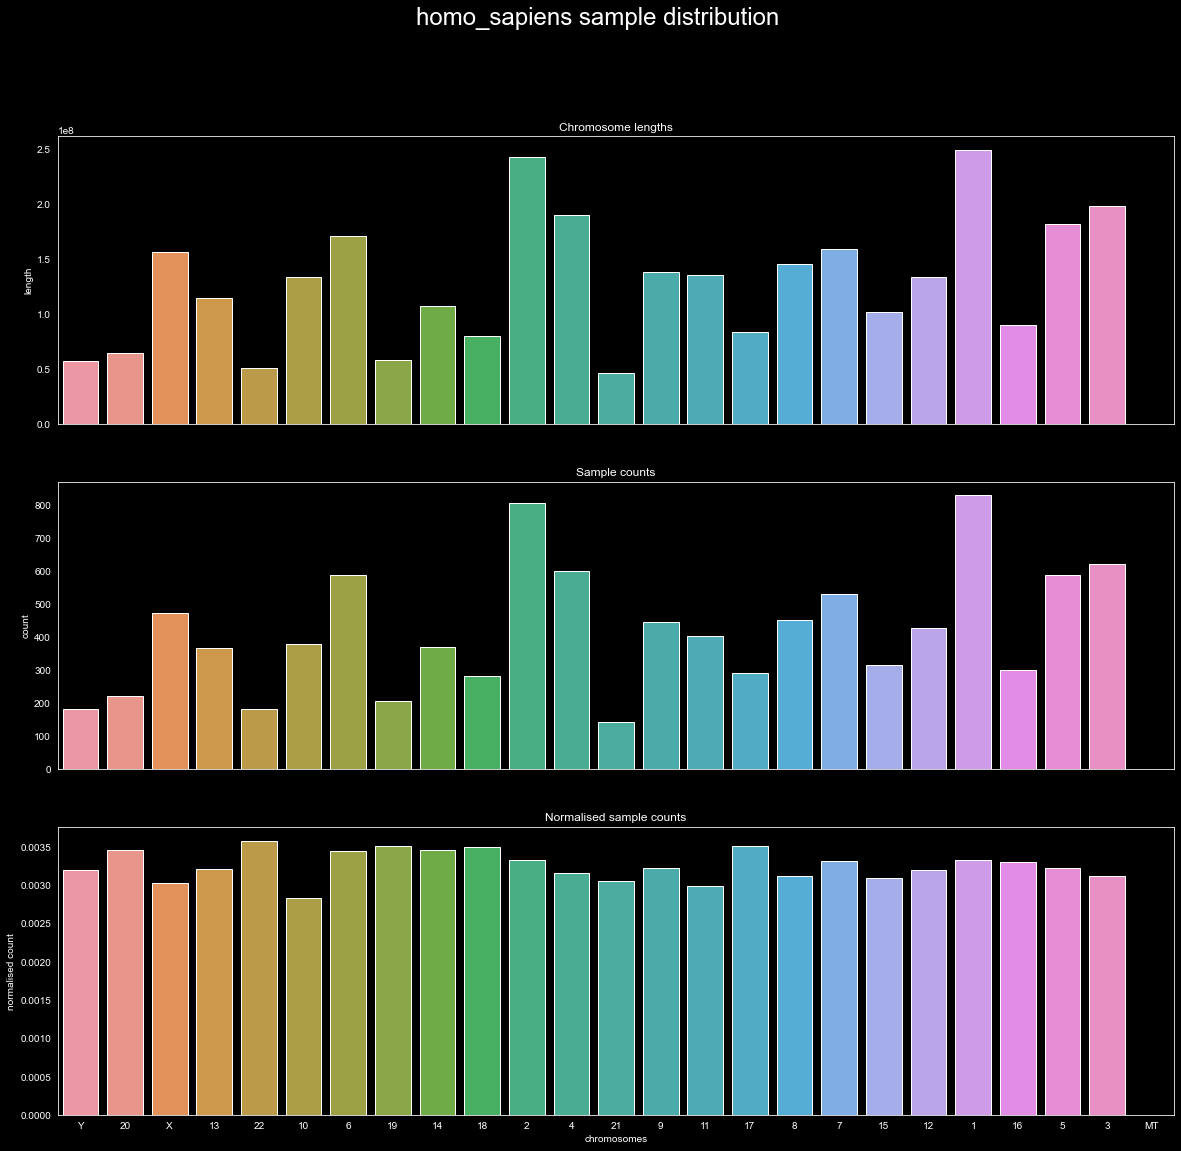

In [7]:

#sns.set_theme(style="darkgrid")
sns.set_style("darkgrid", {'axes.grid' : False})
plt.style.use("dark_background")

fig, ax = plt.subplots(nrows=3, figsize=(20,18), sharex=True)
sns.barplot(ax=ax[0], x='name', y='length', data=df)
ax[0].set_title("Chromosome lengths")
ax[0].set_xlabel("")

sns.barplot(ax=ax[1], x='name', y='count', data=df)
ax[1].set_title("Sample counts")
ax[1].set_xlabel("")

sns.barplot(ax=ax[2], x='name', y='norm', data=df)
ax[2].set_title("Normalised sample counts")
ax[2].set_xlabel("chromosomes")
ax[2].set_ylabel("normalised count")

fig.suptitle(f"{species} sample distribution", size=24)

#[x.grid(b=None, which='major', axis='both') for x in ax]
    
plt.show()



Yay, looks like that worked.

## Sample Region Data
Using the randomly generated region strings, generate query results for each region.

For each region:
 - Sequence
 - all cannonical transcripts
   - **include those partially inside region**
 - Generate labels for positions of
   - exons
   - CDS
   - UTRs ? but these are implied by the exon - CDS difference so duplicate data?
        
        

In [8]:
region_str = lambda r: f"{r['seq_region']}:{r['start']}..{r['end']}:{r['strand']}"

def get_region_seq(region):
        
    ext = f"/sequence/region/{species}/{region_str(region)}"
    r = requests.get(server+ext, headers={ "Content-Type" : "text/plain"})
 
    if not r.ok:
      r.raise_for_status()
 
    return r.text

test_seq = get_region_seq(random_regions[0])
print(test_seq)

...


In [9]:
import numpy as np
def get_region_labels(region, feature_types=['exon', 'cds'], transcript_strategy='cannonical'):
    """
    This should return a numpy ndarray of zeros and ones
    with shape (region_length, len(feature_types)). That is
    a column of exon labels, and a column of CDS labels,
    by default.
    
    Transcript splice variants are handled by transcript_strategy.
    'cannonical' selects only cannonical transcript sub-features.
    'merge' combines overlapping features of the same type,
    if in the same gene, e.g. all exons from all transcripts
    of a particular gene.
    """
    
    
    #print(feature_types)
    fstr = ';'.join([f"feature={f}" for f in feature_types])
    
    # get transcripts and target features in region
    ext = f"/overlap/region/{species}/{region_str(region)}?feature=transcript;{fstr};biotype=protein_coding"
    #print(ext)
    r = requests.get(server+ext, headers={ "Content-Type" : "application/json"})
    
    if not r.ok:
        r.raise_for_status()

    # init labels of zeros
    labels = np.zeros((region['len'], len(feature_types)), dtype=np.int8)
    
    decoded = r.json()
    if not decoded:
        return labels # no features
    
    # Sort by length ascending
    data = sorted(decoded, key=lambda x: x['end'] - x['start'])
    
    # transform results into dict on ids
    # take longest where IDs clash since sorted by increasing length
    features = {f['id']:f for f in data}

    # filter
    label_features = {}
    for fid, f in features.items():
        # Check for target types
        # Check parent if canonical mode
        # Check extents
        if f['feature_type'] not in feature_types:
            #print(f['feature_type'])
            continue
        if features[ f['Parent'] ]['is_canonical'] == 0:
            #print('nope ', f['feature_type'])
            continue
        if f['end'] < region['start'] or f['start'] > region['end']:
            #print(f"2 START {f['start']}  END {f['end']}")
            continue
        #print('yup', f['feature_type'])
        label_features[fid] = f
            
    
    # No desired feature types
    if not label_features:
        return labels
    
    # We'll need to "randomly" access the labels array columns,
    # consistently
    feature_cols = {k:v for v, k in enumerate(feature_types)}
    #print(feature_cols)
    
    # Transfer features to labels
    for fid, f in label_features.items():
        # get the column index to transfer to
        col = feature_cols[ f['feature_type'] ]
        
        # Get ZERO-BASED indices for feature, relative to region
        start = max(0, f['start'] - region['start']) # truncate at start of region
        end   = min(region['len'] - 1, f['end'] - region['start']) # truncate at end of region
        
        # assign positive label 1 to this feature's positions on it's label list
        #print(f"writing {start} {end} ({region['len']}){col}")
        labels[start:end, col] = 1
    
    return labels



#   count = 47
#   test_labels = get_region_labels(random_regions[count])
#   while np.all(test_labels[0]==0) or np.all(test_labels[1]==0) :
#       count += 1
#       test_labels = get_region_labels(random_regions[count])
#   print(count)

### Region Data Generator
Try wrapping it up in a generator.

In [10]:
# a wrapper funtion to get the seq and labels for a given region
def get_region_data(r):
    r['seq'] = get_region_seq(r)
    r['labels'] = get_region_labels(r)
    return r


# test out a generator
def generate_data(region_list):
    for r in region_list:
        print("Yielding ", region_str(r))
        yield get_region_data(r)
        



In [11]:
dgen = generate_data(random_regions)

res = dgen.__next__()

res['labels'].shape

Yielding  6:138849086..138949085:-1


(100000, 2)

## Implement with asyncio + aiohttp
Implemented in the utils script as an aync generator. Ensembl REST calls for each data element (seq and labels only so far) are async calls. Probably unnecessary but nice.

In [42]:
import gabi.utils as gu
from collections import Counter
g = gu.sample_generator()
print(g)
count = 0
async for r in g: 
    count += 1
    print("sample number:", count)
    print("chr:", r['seq_region'])
    print("start:", r['start'])
    print("end:", r['end'])
    print("strand:", r['strand'])
    print("loc:", r['loc'])
    print("length:", r['len'])
    print("counts:\n", *[f"  {k}: {v}\n" for k, v in sorted(dict(Counter(r['seq'])).items())] )
    print("labels list shape:", r['labels'].shape)
    print("--------")
    Counter

<async_generator object sample_generator at 0x13f486dc0>
sample number: 1
chr: 2
start: 40615568
end: 40616567
strand: 1
loc: 2:40615568..40616567:1
length: 1000
counts:
   A: 308
   C: 180
   G: 211
   T: 301

labels list shape: (1000, 1)
--------
sample number: 2
chr: 10
start: 112012745
end: 112013744
strand: 1
loc: 10:112012745..112013744:1
length: 1000
counts:
   A: 320
   C: 206
   G: 226
   T: 248

labels list shape: (1000, 1)
--------
sample number: 3
chr: 7
start: 10007904
end: 10008903
strand: -1
loc: 7:10007904..10008903:-1
length: 1000
counts:
   A: 325
   C: 172
   G: 252
   T: 251

labels list shape: (1000, 1)
--------
sample number: 4
chr: 1
start: 36907734
end: 36908733
strand: -1
loc: 1:36907734..36908733:-1
length: 1000
counts:
   A: 260
   C: 237
   G: 282
   T: 221

labels list shape: (1000, 1)
--------
sample number: 5
chr: 4
start: 35514311
end: 35515310
strand: -1
loc: 4:35514311..35515310:-1
length: 1000
counts:
   A: 392
   C: 136
   G: 161
   T: 311

labels li